In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Models
import xgboost as xgb
import lightgbm as lgb

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
df = pd.read_csv("/content/drive/MyDrive/grammatical/intrusion_dataset.txt")

print(df.shape)
df.head()

(1244, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
print(df.info())
print(df.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     1244 non-null   int64  
 1   protocol_type                1244 non-null   object 
 2   service                      1244 non-null   object 
 3   flag                         1244 non-null   object 
 4   src_bytes                    1244 non-null   int64  
 5   dst_bytes                    1244 non-null   int64  
 6   land                         1244 non-null   int64  
 7   wrong_fragment               1244 non-null   int64  
 8   urgent                       1244 non-null   int64  
 9   hot                          1244 non-null   int64  
 10  num_failed_logins            1244 non-null   int64  
 11  logged_in                    1244 non-null   int64  
 12  num_compromised              1244 non-null   int64  
 13  root_shell        

In [5]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [6]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label'],
      dtype='object')

In [8]:
df.dtypes

,0
duration,int64
protocol_type,object
service,object
flag,object
src_bytes,int64
dst_bytes,int64
land,int64
wrong_fragment,int64
urgent,int64
hot,int64


In [31]:
# Save label encoders
encoders = {}

for col in ['protocol_type', 'service', 'flag', 'label']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "/content/drive/MyDrive/grammatical/encoders.pkl")

print("✅ Model and encoders saved successfully")

✅ Model and encoders saved successfully


In [10]:
X = df.drop("label", axis=1)
y = df["label"]

In [11]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get importance
importances = model.feature_importances_
feature_names = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(15))

                        Feature  Importance
4                     src_bytes    0.183233
5                     dst_bytes    0.118299
33       dst_host_same_srv_rate    0.077337
3                          flag    0.075739
32           dst_host_srv_count    0.071762
28                same_srv_rate    0.069054
11                    logged_in    0.042626
35  dst_host_same_src_port_rate    0.039716
29                diff_srv_rate    0.033517
22                        count    0.030528
37         dst_host_serror_rate    0.029349
1                 protocol_type    0.028614
25              srv_serror_rate    0.023887
34       dst_host_diff_srv_rate    0.021766
23                    srv_count    0.021560


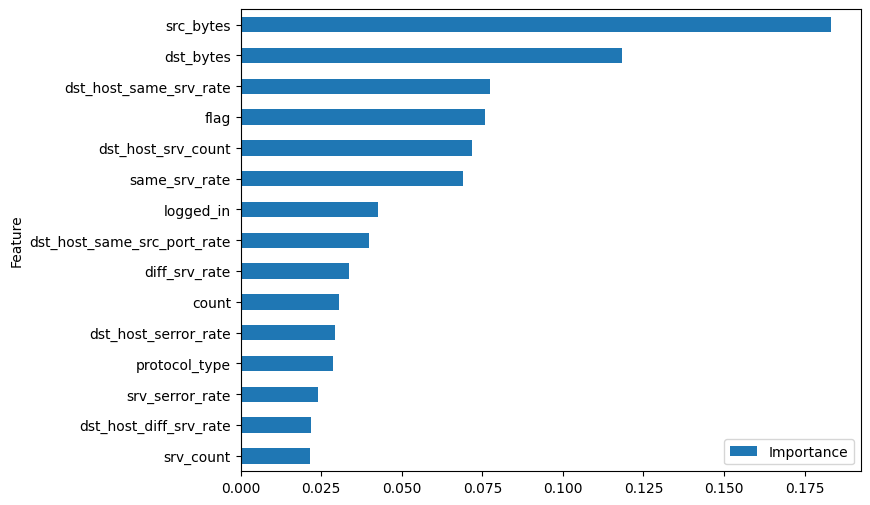

In [12]:
feat_imp.head(15).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

In [13]:
top_features = feat_imp.head(15)['Feature'].tolist()

X_selected = X[top_features]

print("Selected Features:", top_features)

Selected Features: ['src_bytes', 'dst_bytes', 'dst_host_same_srv_rate', 'flag', 'dst_host_srv_count', 'same_srv_rate', 'logged_in', 'dst_host_same_src_port_rate', 'diff_srv_rate', 'count', 'dst_host_serror_rate', 'protocol_type', 'srv_serror_rate', 'dst_host_diff_srv_rate', 'srv_count']


In [14]:
df_selected = df[top_features + ['label']]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
y_pred = rf_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9959839357429718

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       122
           1       0.99      1.00      1.00       127

    accuracy                           1.00       249
   macro avg       1.00      1.00      1.00       249
weighted avg       1.00      1.00      1.00       249


Confusion Matrix:
 [[121   1]
 [  0 127]]


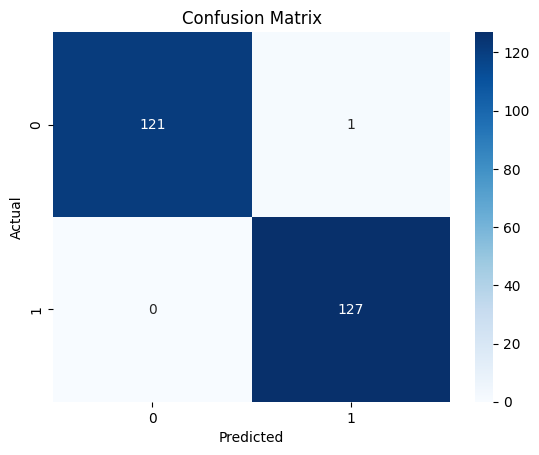

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier

In [21]:
et = ExtraTreesClassifier(n_estimators=200, random_state=42)

In [22]:
voting_model = VotingClassifier(
    estimators=[

        ('et', et)

    ],
    voting='soft'   # important
)

In [23]:
et.fit(X_train, y_train)
voting_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score


et_pred = et.predict(X_test)
vote_pred = voting_model.predict(X_test)

In [24]:

et_acc = accuracy_score(y_test, et_pred)
vote_acc = accuracy_score(y_test, vote_pred)

print("Extra Trees Accuracy:", et_acc)

print("Voting Classifier Accuracy:", vote_acc)

Extra Trees Accuracy: 0.9919678714859438
Voting Classifier Accuracy: 0.9919678714859438


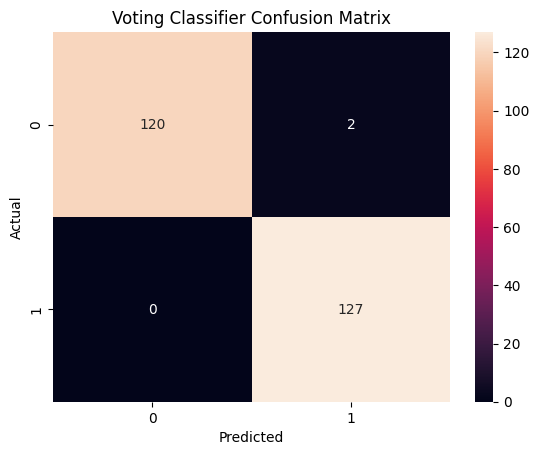

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, vote_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, vote_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       122
           1       0.98      1.00      0.99       127

    accuracy                           0.99       249
   macro avg       0.99      0.99      0.99       249
weighted avg       0.99      0.99      0.99       249



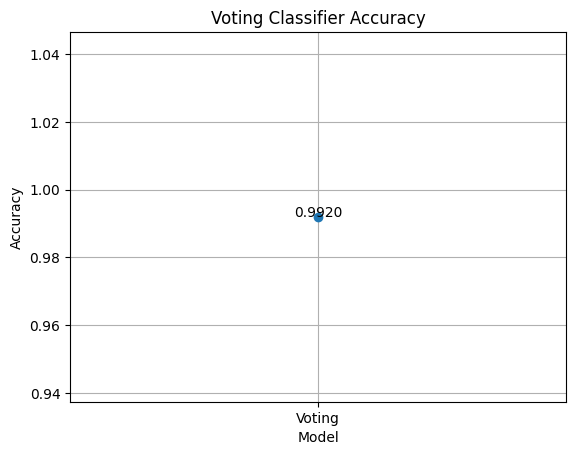

In [35]:
import matplotlib.pyplot as plt

# Only voting accuracy (single model)
models = ['Voting']
accuracies = [vote_acc]

plt.figure()

plt.plot(models, accuracies, marker='o')

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Voting Classifier Accuracy")

# Show value
for i, acc in enumerate(accuracies):
    plt.text(i, acc, f"{acc:.4f}", ha='center')

plt.grid()

plt.show()

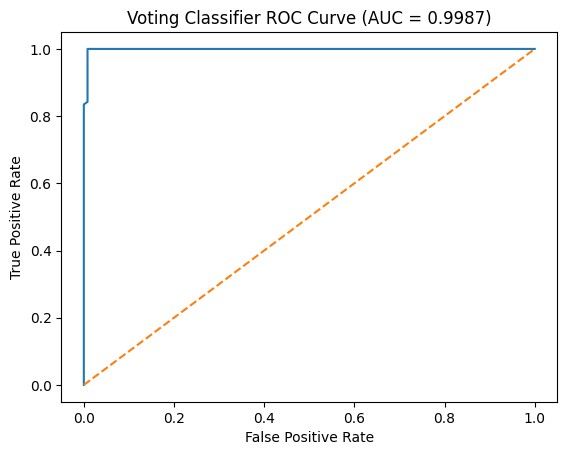

In [37]:
from sklearn.metrics import roc_curve, auc

y_prob = voting_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Voting Classifier ROC Curve (AUC = {roc_auc:.4f})")

plt.show()

In [27]:
import joblib

# Save model
joblib.dump(voting_model, "/content/drive/MyDrive/grammatical/voting_model.pkl")

# Save selected features
joblib.dump(top_features, "/content/drive/MyDrive/grammatical/features.pkl")



✅ Model and encoders saved successfully


In [32]:
import joblib
import pandas as pd

# 🔹 Load saved files
model = joblib.load("/content/drive/MyDrive/grammatical/voting_model.pkl")
features = joblib.load("/content/drive/MyDrive/grammatical/features.pkl")
encoders = joblib.load("/content/drive/MyDrive/grammatical/encoders.pkl")

# 🔹 New input
new_data = {
    'duration': 0,
    'protocol_type': 'tcp',
    'service': 'http',
    'flag': 'SF',
    'src_bytes': 181,
    'dst_bytes': 5450,
    'count': 2,
    'srv_count': 2,
    'serror_rate': 0.0,
    'srv_serror_rate': 0.0,
    'same_srv_rate': 1.0,
    'dst_host_count': 255,
    'dst_host_srv_count': 255,
    'dst_host_same_srv_rate': 1.0,
    'dst_host_serror_rate': 0.0
}

# 🔹 Convert to DataFrame
input_df = pd.DataFrame([new_data])

# 🔥 Step 1: Encode categorical safely
for col in ['protocol_type', 'service', 'flag']:
    if col in input_df.columns:
        if input_df[col].iloc[0] in encoders[col].classes_:
            input_df[col] = encoders[col].transform(input_df[col])
        else:
            print(f"⚠️ Unknown value '{input_df[col].iloc[0]}' in column '{col}'")
            input_df[col] = 0   # fallback

# 🔥 Step 2: Ensure all required features exist
for col in features:
    if col not in input_df.columns:
        input_df[col] = 0

# 🔥 Step 3: Arrange feature order
input_df = input_df[features]

# 🔹 Predict
prediction = model.predict(input_df)

# 🔹 Decode output
output = encoders['label'].inverse_transform(prediction)

print("✅ Prediction:", output[0])

✅ Prediction: normal


In [33]:
import joblib
import pandas as pd

# 🔹 Load saved files
model = joblib.load("/content/drive/MyDrive/grammatical/voting_model.pkl")
features = joblib.load("/content/drive/MyDrive/grammatical/features.pkl")
encoders = joblib.load("/content/drive/MyDrive/grammatical/encoders.pkl")

# 🔥 Multiple test inputs (Normal + Attack)
test_data = [
    # ✅ Normal traffic
    {
        'duration': 0,
        'protocol_type': 'tcp',
        'service': 'http',
        'flag': 'SF',
        'src_bytes': 181,
        'dst_bytes': 5450,
        'count': 2,
        'srv_count': 2,
        'serror_rate': 0.0,
        'srv_serror_rate': 0.0,
        'same_srv_rate': 1.0,
        'dst_host_count': 255,
        'dst_host_srv_count': 255,
        'dst_host_same_srv_rate': 1.0,
        'dst_host_serror_rate': 0.0
    },

    # 🚨 Anomaly / Attack-like input
    {
        'duration': 0,
        'protocol_type': 'tcp',
        'service': 'http',
        'flag': 'REJ',
        'src_bytes': 0,
        'dst_bytes': 0,
        'count': 500,
        'srv_count': 500,
        'serror_rate': 1.0,
        'srv_serror_rate': 1.0,
        'same_srv_rate': 0.0,
        'dst_host_count': 255,
        'dst_host_srv_count': 10,
        'dst_host_same_srv_rate': 0.1,
        'dst_host_serror_rate': 1.0
    }
]

# 🔹 Convert to DataFrame
input_df = pd.DataFrame(test_data)

# 🔥 Encode categorical safely
for col in ['protocol_type', 'service', 'flag']:
    if col in input_df.columns:
        input_df[col] = input_df[col].apply(
            lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else 0
        )

# 🔥 Ensure all required features exist
for col in features:
    if col not in input_df.columns:
        input_df[col] = 0

# 🔥 Arrange feature order
input_df = input_df[features]

# 🔹 Predict
predictions = model.predict(input_df)

# 🔹 Decode output
outputs = encoders['label'].inverse_transform(predictions)

# 🔹 Show results
for i, out in enumerate(outputs):
    print(f"Sample {i+1} Prediction:", out)

Sample 1 Prediction: normal
Sample 2 Prediction: anomaly


In [34]:
!pip freeze > /content/drive/MyDrive/grammatical/req_3.12.12.txt